## CS 598 PSL Fall 2026
### Coding Assignment 5

- Anirudh Eswara
- Ryan Lenea
- Mark Synowiec
- Robert Walker

## Problem 1 [50 points]

In this problem we cluster countries using a 2022 snapshot of World Bank development indicators. The file countries 2022.csv is posted on Coursera. Each row is a country. The columns you may use as features are

gdp pc ppp, fertility, life exp, u5 mort, urban pct.

Do not use region, income, population, iso3, or country as features — those are labels for interpretation afterwards. Take a logarithm of gdp pc ppp before clustering (income is heavily right-skewed). Then scale (or standardize) all five features: the Euclidean metric in K-means is sensitive to units, and GDP would otherwise dominate fertility and mortality.

Our goal is to recover groups of countries with similar development profiles, and then to say where Greece sits in that partition.

In [1]:
import pandas as pd

file_path = "countries_2022.csv"

try:
    df = pd.read_csv(file_path)

    display(df.head())
except Exception as e:
    print(f"An unexpected error occurred: {e}")

,iso3,country,year,region,income,population,gdp_pc_ppp,fertility,life_exp,u5_mort,urban_pct
0,AFG,Afghanistan,2022,"Middle East, North Africa, Afghanistan & Pakistan",Low income,40578842,1981.710168,4.932,65.617,56.8,25.393925
1,ALB,Albania,2022,Europe & Central Asia,Upper middle income,2451636,19388.792728,1.355,78.769,9.4,57.864348
2,DZA,Algeria,2022,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income,45477389,14782.200297,2.817,76.129,22.3,74.179586
3,AND,Andorra,2022,Europe & Central Asia,High income,79705,63913.383508,1.071,84.016,2.7,88.754877
4,AGO,Angola,2022,Sub-Saharan Africa,Lower middle income,35635029,8750.993630,5.209,64.246,51.9,69.050619


(a) Use K-Means Clustering to assign each country to a cluster:

i. Use the Gap Statistic and the Silhouette Statistic to determine the optimal
number of clusters kgap and ksil. Fit the K-means algorithm to the data for both ks.
Use multiple random starts (e.g. nstart/n init of at least 25).
Note: If you get the same k that is ok! You have more evidence that this is probably
the appropriate number of clusters.

ii. Plot fertility vs. life exp and color code the clusters for both ks. Mark Greece
on the plot. Comment on the separability of the clusters. Keep in mind that this is
a 2-dimensional projection of a 5-dimensional clustering.

iii. Interpret the clusters. Compute summary statistics for each cluster (mean fertility,
life expectancy, under-5 mortality, urban share, and GDP per capita). Which cluster
contains Greece? Name two other countries in that cluster and two countries that
land far from Greece. Does the partition line up with the World Bank region or
income labels, or does Greece sit with a mixed group?

(b) Use Hierarchical Clustering to assign a cluster to each country. Use complete linkage
and the same scaled features as in part (a).

i. Plot the dendrogram. If the labels are unreadable, plot a truncated tree or label only
a subset that includes Greece.

ii. Cut the dendrogram at kgap and at ksil from part (a) (if the two ks coincide, one cut is
enough). Repeat questions (a-ii) and (a-iii) for these hierarchical assignments. Does
Greece stay with the same neighbors as in part (a)? Comment on the differences
and/or similarities.

## Problem 2 [50 points]

In this problem we are going to create a simulated data set to illustrate the use of spectral
clustering. In the literature, what we are going to simulate is known as the “Two Moons”
data. Mathematically, each moon is a semicircle of radius r that can be parametrized in polar
coordinates as

$x = r cos θ$, $y = r sin θ$

for the upper half, and

$x^′ = dx − r cos θ$, $y^′ = −r sin θ − dy$

for the lower half, shifted by $dx$ and $dy$ so that the two semicircles do not overlap. Here $θ ∈ [0, π]$
and $r$ is the radius.

Create the two moons synthetic data of size n = 200 (100 points per moon) as follows:

1. For $r = 2$, sample $θ^1_i ∼ Uniform[0, π]$, and compute $x_i = r cos θ^1_i$ and $y_i = r sin θ^1_i$. Add
some noise to each coordinate, e.g. independent $N(0, 0.052)$ draws (standard deviation
0.05, not variance 0.05). Assign the label ‘0‘ to this moon.

2. For $r = 2$, sample $θ^2_i ∼ Uniform[0, π]$, and compute $x^′_i = 1 − 2 cos θ^2_i$ and $y^′_i = −2 sin θ^2_i − 0.5$. Add the same noise to each coordinate. Assign the label ‘1‘ to this moon.

3. Combine everything into a data frame with 3 columns: the two coordinates and the
generating label. This is your data set!

4. Plot it!

If you use n = 200 and set.seed(598) (in R), you should get something similar to the
following:

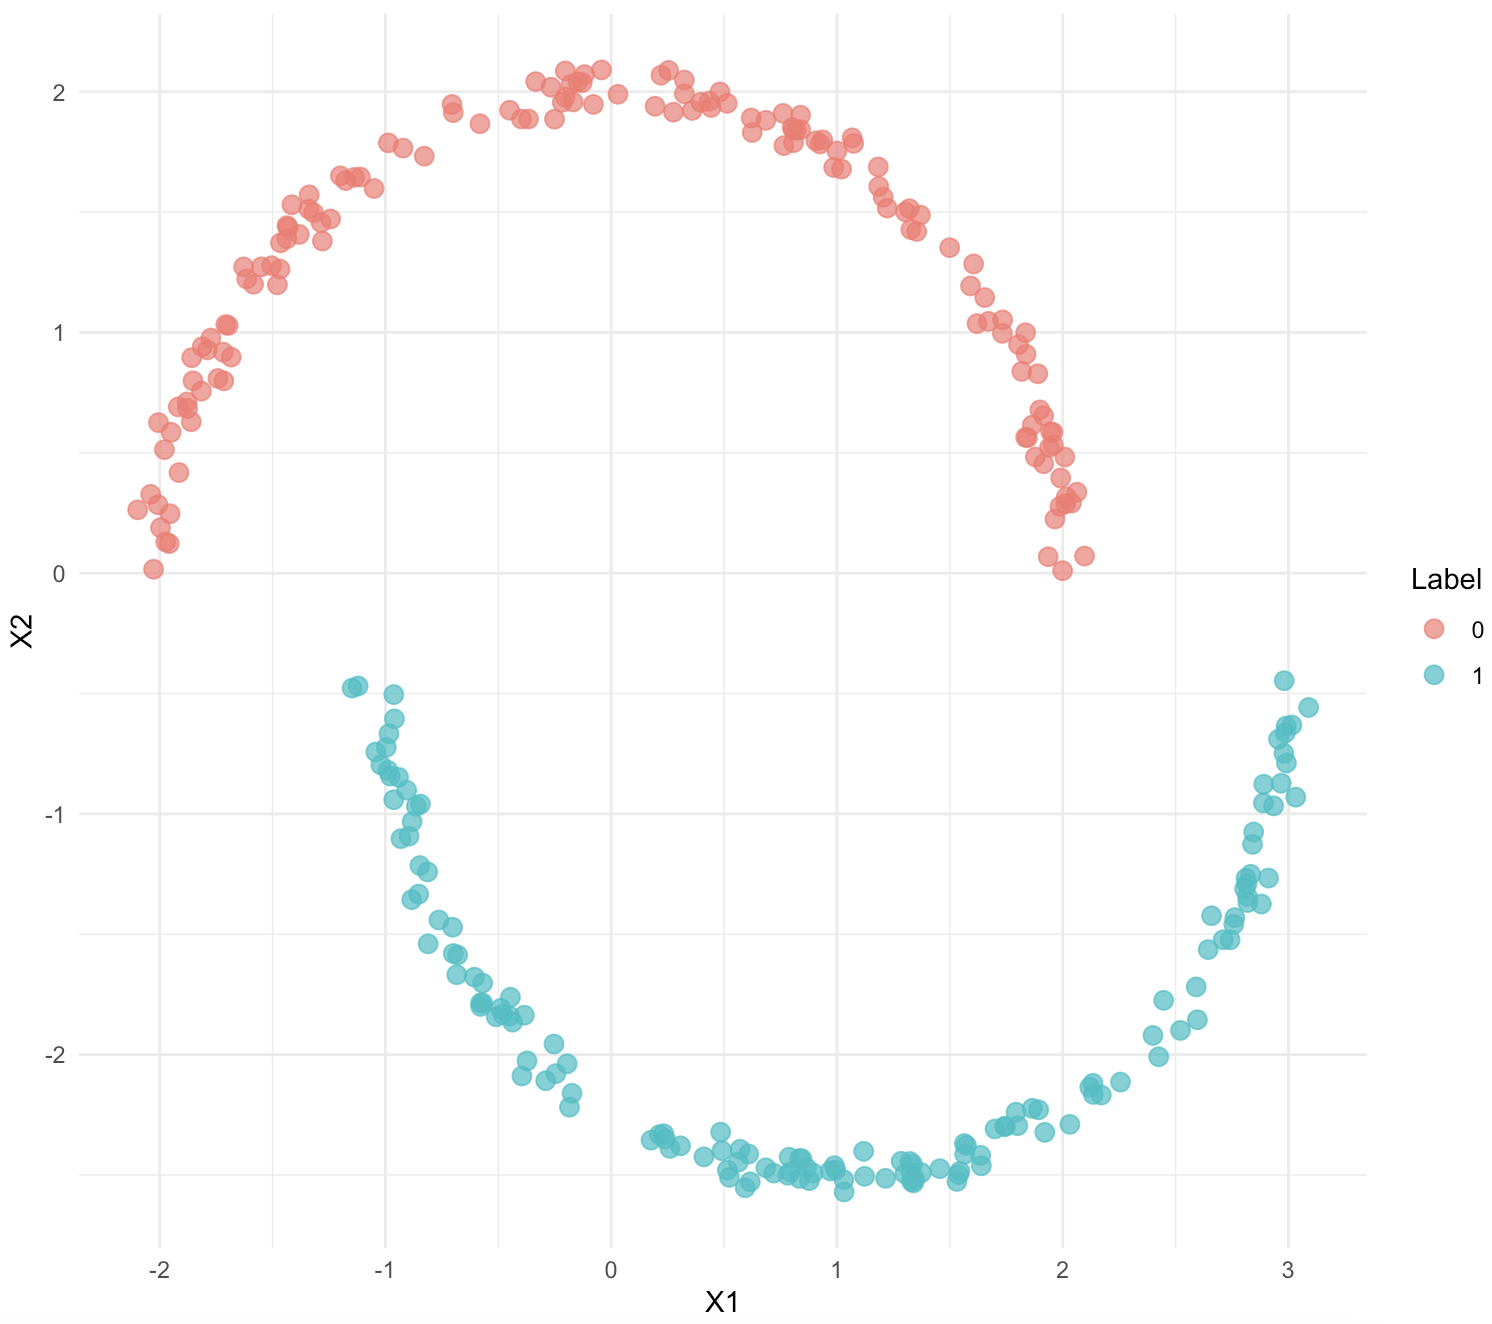

Note: Python has a function that creates this synthetic data automatically, but you will lose
all the fun! It is ok to use it, but make sure that you plot your synthetic data.